# Import Libraries

Import all necessary libraries for data manipulation, visualization, preprocessing, model building, and evaluation.

In [48]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model Selection
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Loading Dataset

Loading the training and testing dataset into a Pandas DataFrame.

In [49]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [50]:
#First 5 rows of training data
train_df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [51]:
# First 5 rows of testing data
test_df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,15202,23,Male,B.Tech,Civil,7.32,2,4,5,6,56,6,1,0,Placed
1,4573,24,Female,MCA,ME,4.76,0,1,1,4,37,4,0,3,Not Placed
2,34424,20,Male,BCA,ME,6.16,0,3,3,8,68,6,1,3,Not Placed
3,38881,19,Male,B.Sc,IT,8.77,2,5,8,5,83,6,3,0,Placed
4,30191,23,Male,B.Tech,ME,7.63,0,3,4,6,66,7,1,0,Not Placed


# Dataset Inspection

Understanding the structure and characteristics of the datasets.

In [52]:
# Shape of train and test data
print(train_df.shape)
print(test_df.shape)

(45000, 15)
(5000, 15)


In [53]:
# Info  of the dataset
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  object 
 3   Degree                45000 non-null  object 
 4   Branch                45000 non-null  object 
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  int64  
 10  Aptitude_Test_Score   45000 non-null  int64  
 11  Soft_Skills_Rating    45000 non-null  int64  
 12  Certifications        45000 non-null  int64  
 13  Backlogs              45000 non-null  int64  
 14  Placement_Status      45000 non-null  object 
dtypes: float64(1), int6

In [54]:
# Statistical summary 
train_df.describe()

,Student_ID,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,24977.962600,20.999333,7.002290,0.774089,3.734222,5.691800,5.501644,69.385356,5.501644,1.800956,0.888133
std,14425.605704,1.995071,0.993855,0.844750,0.923738,1.994674,1.515374,13.909710,1.238722,0.650104,0.970954
min,1.000000,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000
25%,12509.750000,19.000000,6.320000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000
50%,24957.500000,21.000000,7.000000,1.000000,4.000000,6.000000,6.000000,69.000000,5.000000,2.000000,1.000000
75%,37475.250000,23.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000
max,50000.000000,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000


In [55]:
# Checking for missing values
train_df.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [56]:
test_df.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [57]:
# Checking for duplicate values
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())
#No duplicate records are found.

0
0


In [58]:
# Checking common rows between train and test datasets
common_rows = pd.merge(train_df, test_df, how='inner')

print("Number of common rows:", len(common_rows))

# Display the common rows
common_rows.head()

Number of common rows: 0


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status


# Data Cleaning

### Removing Student_ID

Student_ID is a unique identifier and does not contribute to prediction.

In [59]:
train_df.drop("Student_ID", axis=1, inplace=True)
test_df.drop("Student_ID", axis=1, inplace=True)

# Exploratory Data Analysis

Target Distribution

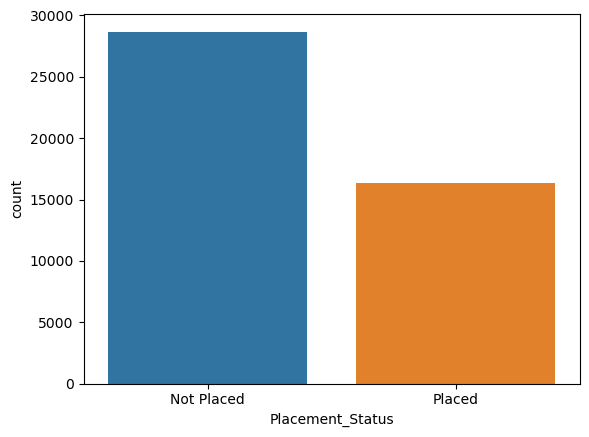

In [60]:
sns.countplot(x='Placement_Status', data=train_df)
plt.show()

The dataset contains more Not Placed students than Placed students.

Distribution of Numeric Features

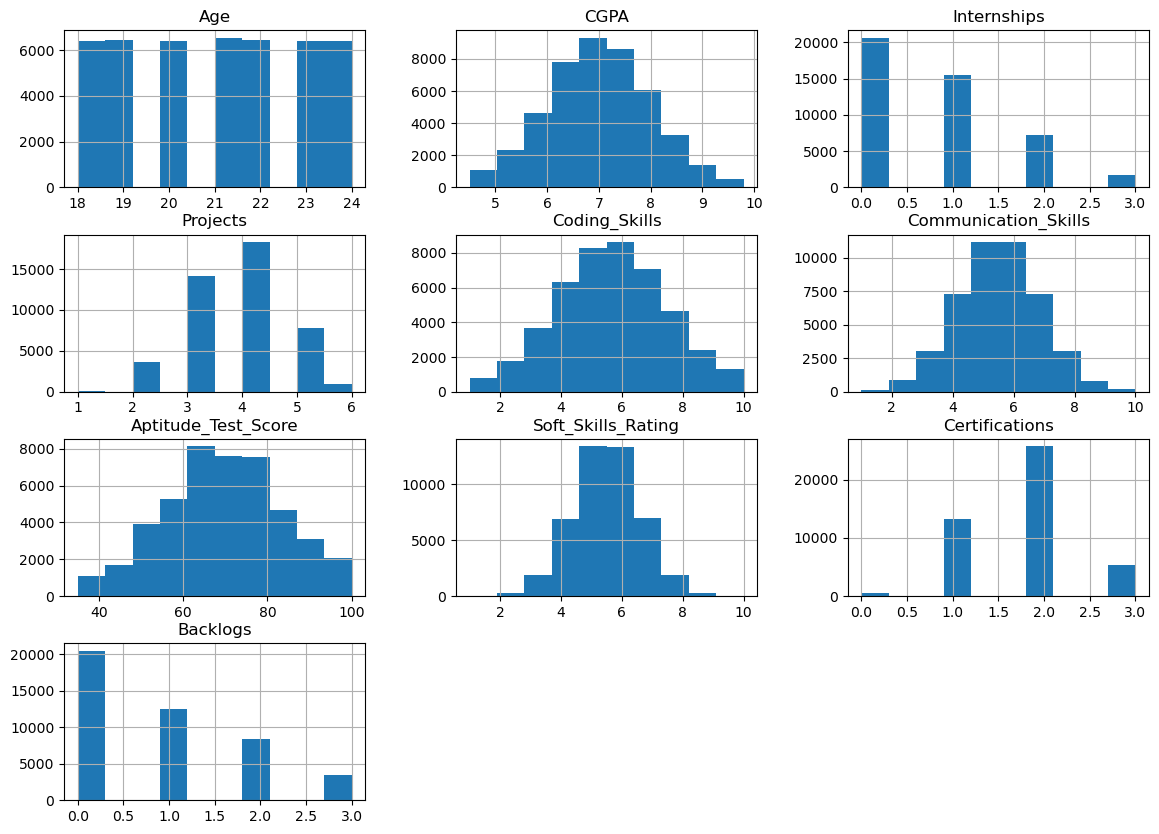

In [61]:
train_df.hist(figsize=(14,10))
plt.show()

Gender wise Count and Placement Status

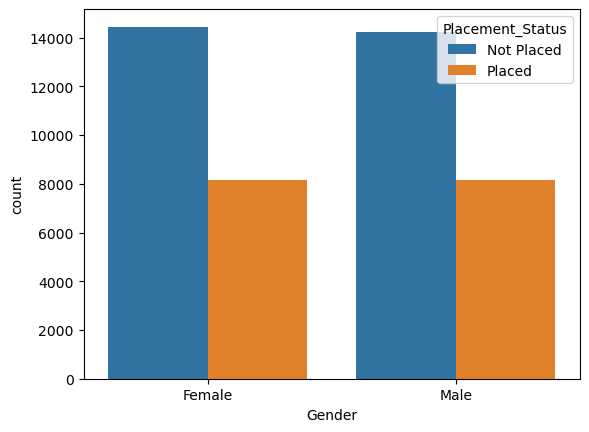

In [62]:
sns.countplot(x='Gender', hue='Placement_Status', data=train_df)
plt.show()

Do academic performance and technical abilities differ between placed and non-placed students?

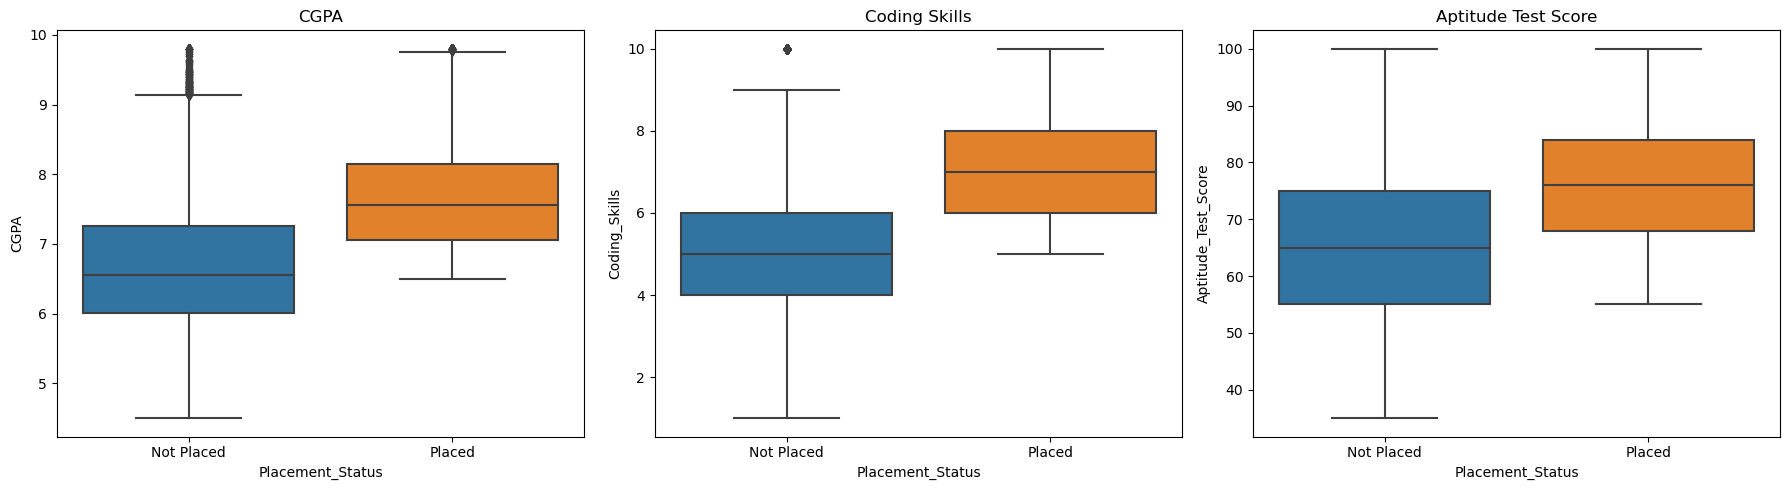

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CGPA
sns.boxplot(x='Placement_Status', y='CGPA', data=train_df, ax=axes[0])
axes[0].set_title('CGPA')

# Coding Skills
sns.boxplot(x='Placement_Status', y='Coding_Skills', data=train_df, ax=axes[1])
axes[1].set_title('Coding Skills')

# Aptitude Test Score
sns.boxplot(x='Placement_Status', y='Aptitude_Test_Score', data=train_df, ax=axes[2])
axes[2].set_title('Aptitude Test Score')

plt.tight_layout()
plt.show()

Placed students generally exhibit higher CGPA, coding skill scores, and aptitude test scores than non-placed students, indicating that academic performance and technical aptitude play an important role in placement outcomes.

Are internships associated with better placement outcomes?

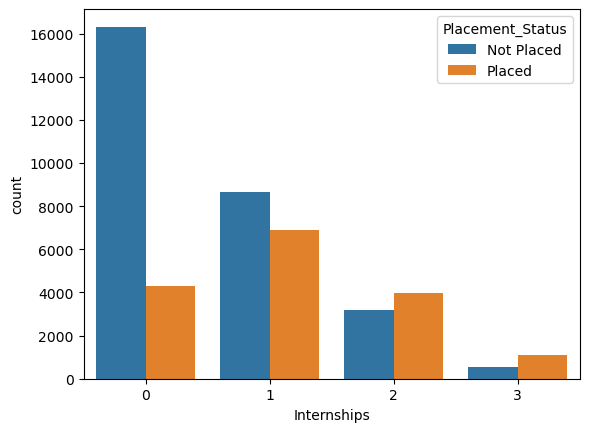

In [64]:
sns.countplot(x='Internships', hue='Placement_Status', data=train_df)
plt.show()

Placement rates improve as internship count increases

Is there a relationship between CGPA and aptitude test scores, and does placement status influence this relationship?

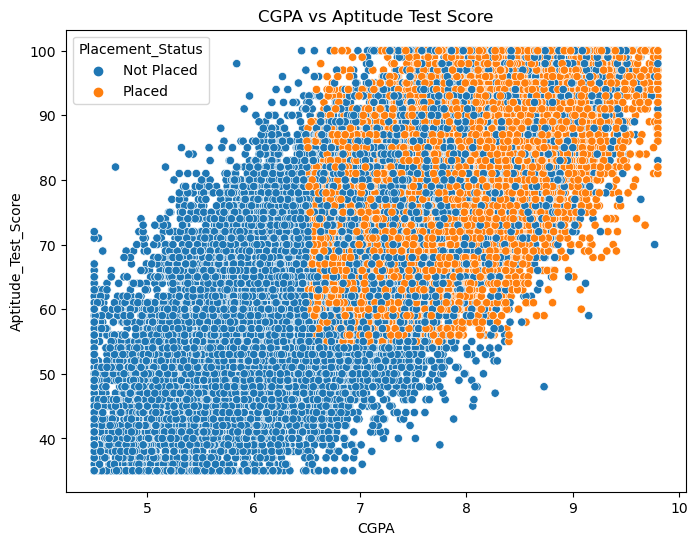

In [65]:
# Scatter plot showing the relationship between CGPA and Aptitude Test Score
# Points are colored according to placement status

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='CGPA',
    y='Aptitude_Test_Score',
    hue='Placement_Status',
    data=train_df
)

plt.title('CGPA vs Aptitude Test Score')
plt.show()

Students with higher CGPA and aptitude scores tend to have better placement outcomes. Placed students are concentrated in the upper-right region of the plot.

How do backlogs affect the placement status?

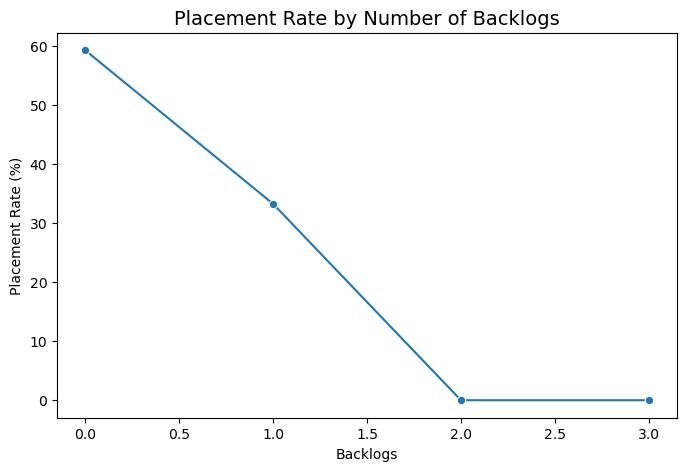

In [66]:
# Calculate average CGPA grouped by number of backlogs
backlog_analysis = (train_df.groupby('Backlogs').agg({'CGPA':'mean',
        'Placement_Status':lambda x: (x=='Placed').mean()*100}))

# Rename columns
backlog_analysis.columns = ['Average_CGPA', 'Placement_Rate']

# Plot placement rate
plt.figure(figsize=(8,5))
sns.lineplot(x=backlog_analysis.index,
    y=backlog_analysis['Placement_Rate'],
    marker='o')

plt.title('Placement Rate by Number of Backlogs', fontsize=14)
plt.ylabel('Placement Rate (%)')
plt.show()

Placement rates tend to decrease as the number of backlogs increases, highlighting the importance of maintaining a strong academic record.

How are coding skills and communication skills related, and does placement status affect this relationship?

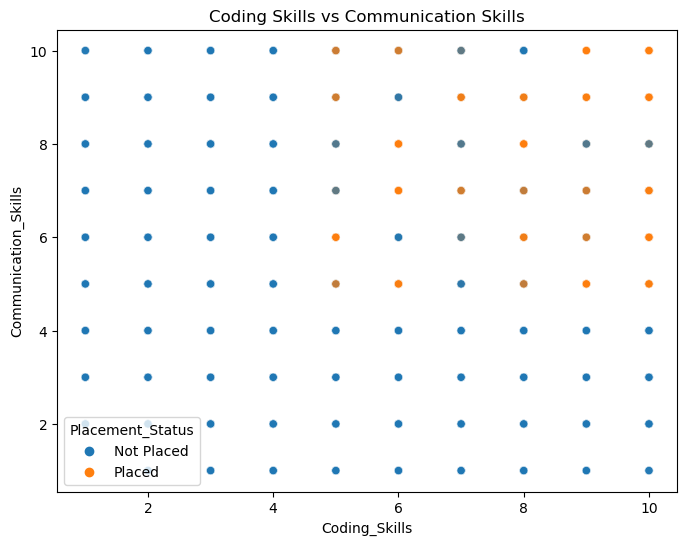

In [67]:
# Scatter plot to analyze the relationship between
# coding skills and communication skills

plt.figure(figsize=(8,6))
sns.scatterplot(x='Coding_Skills', y='Communication_Skills', hue='Placement_Status', alpha=0.7, data=train_df)
plt.title('Coding Skills vs Communication Skills')
plt.show()

Students possessing strong technical and communication skills are more likely to be placed. Successful candidates generally cluster in the higher skill regions

Do certifications improve placement chances?

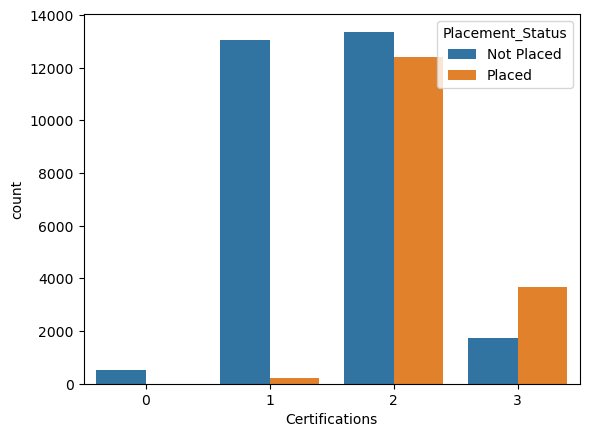

In [68]:
sns.countplot(x='Certifications', hue='Placement_Status', data=train_df)
plt.show()

Students with more certifications tend to have better placement outcomes.

Which features are most strongly correlated with placement status?

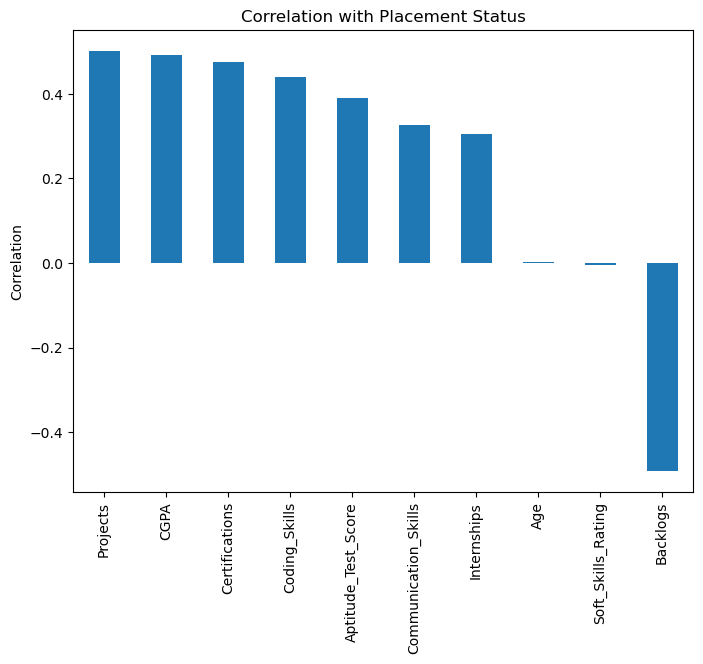

In [69]:
# Convert target variable into numerical form temporarily

temp_df = train_df.copy()
temp_df['Placement_Status'] = temp_df['Placement_Status'].map(
    {'Not Placed':0, 'Placed':1})

# Compute correlations with the target variable

correlation_with_target = (temp_df.corr(numeric_only=True)['Placement_Status']
    .sort_values(ascending=False))

# Remove self-correlation
correlation_with_target = correlation_with_target.drop('Placement_Status')

# Plot correlations

plt.figure(figsize=(8,6))
correlation_with_target.plot(kind='bar')
plt.ylabel('Correlation')
plt.title('Correlation with Placement Status')
plt.show()

CGPA, coding skills, aptitude scores, projects, and internships show positive relationships with placement outcomes, whereas backlogs tend to have a negative relationship

What is the average profile of placed and non-placed students?

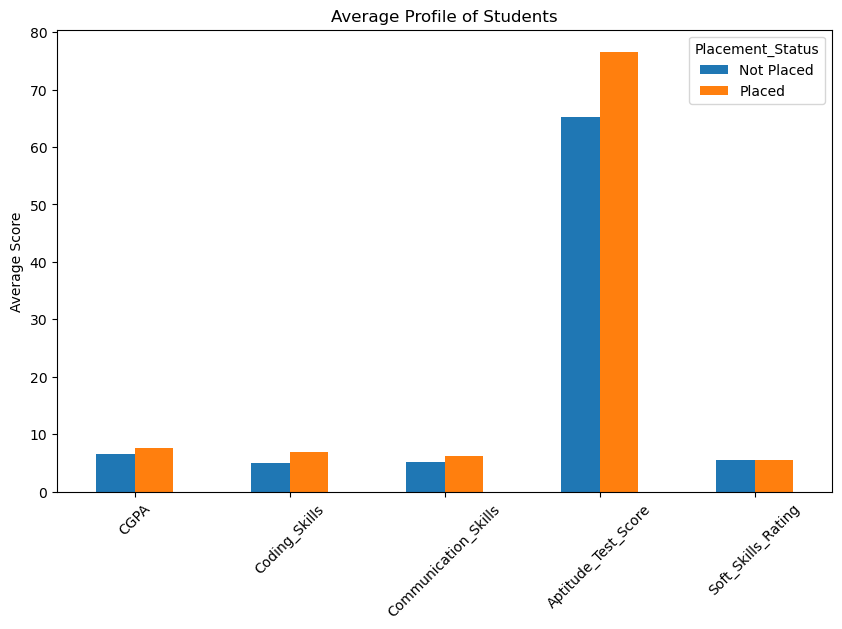

In [70]:
# Calculate average values for selected features
# based on placement status
average_profile = train_df.groupby('Placement_Status')[['CGPA', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score',
        'Soft_Skills_Rating']].mean()

# Plot the averages
average_profile.T.plot(kind='bar', figsize=(10,6))
plt.ylabel('Average Score')
plt.title('Average Profile of Students')
plt.xticks(rotation=45)
plt.show()

Placed students consistently exhibit higher average scores across academic, technical, and soft-skill dimensions

Which numerical features are most strongly associated with placement status?

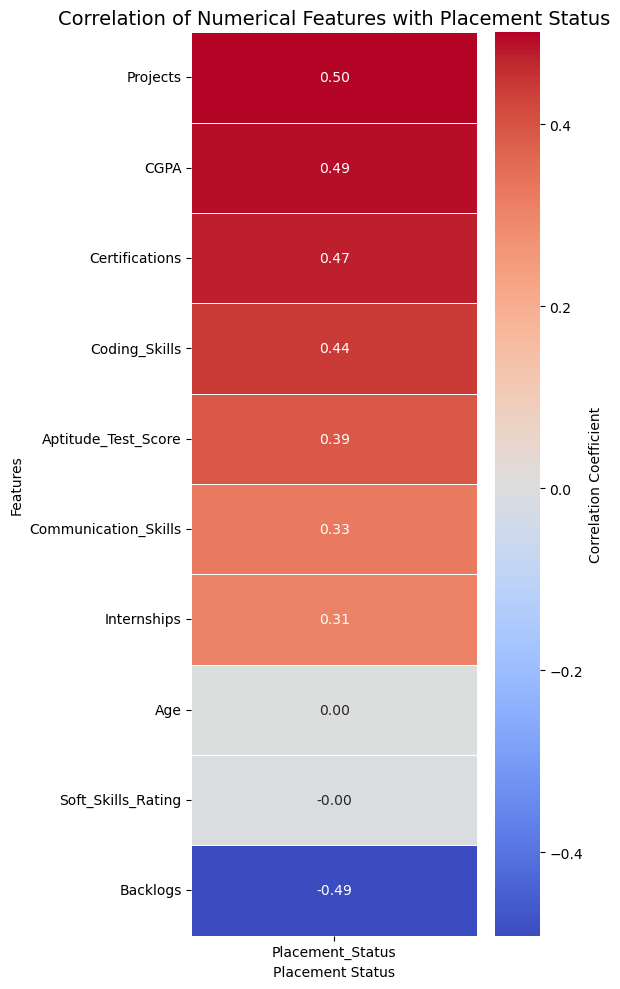

In [71]:
# Create a copy of the training data
temp_df = train_df.copy()
# Encode target variable for correlation analysis
temp_df['Placement_Status'] = temp_df['Placement_Status'].map({'Not Placed': 0, 'Placed': 1})

# Select only numerical columns
numerical_cols = temp_df.select_dtypes(include=np.number)

# Compute correlation of all numerical features with the target variable
target_corr = numerical_cols.corr()[['Placement_Status']]

# Sort correlations in descending order
target_corr = target_corr.sort_values(by='Placement_Status', ascending=False)

# Remove self-correlation
target_corr = target_corr.drop('Placement_Status')

# Plot heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(target_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation of Numerical Features with Placement Status', fontsize=14)
plt.xlabel('Placement Status')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Which branch demonstrates the highest placement rate?

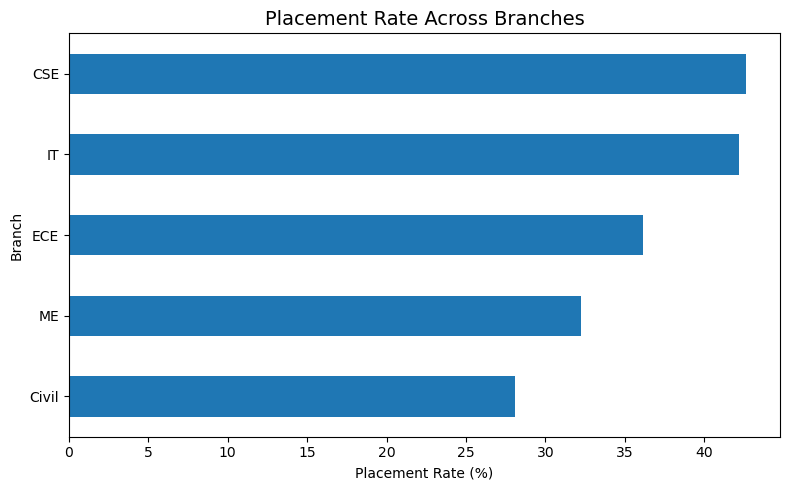

In [72]:
# Calculate placement percentage branch-wise
branch_placement_rate = (train_df.groupby('Branch')['Placement_Status'].value_counts(normalize=True).unstack()*100)
# Plot placement percentages
branch_placement_rate['Placed'].sort_values().plot(kind='barh', figsize=(8,5))
plt.xlabel('Placement Rate (%)')
plt.title('Placement Rate Across Branches', fontsize=14)
plt.tight_layout()
plt.show()

Placement rates vary across branches, indicating that academic specialization may influence employment opportunities.

# Feature Engineering

In [73]:
# Creating a new column `total experience` based on internship, projects and certificatiom
train_df['Total_Experience'] = (train_df['Internships'] + train_df['Projects'] + train_df['Certifications'])

test_df['Total_Experience'] = (test_df['Internships'] + test_df['Projects'] + test_df['Certifications'])

In [74]:
# Creating a new column `overall skill score` based on coding skills, communication skills and soft skills
train_df['Overall_Skill_Score'] = (train_df['Coding_Skills'] + train_df['Communication_Skills'] + train_df['Soft_Skills_Rating'])

test_df['Overall_Skill_Score'] = (test_df['Coding_Skills'] + test_df['Communication_Skills'] + test_df['Soft_Skills_Rating'])

# Data Preprocessing

### Encoding Categorical Variables

In [75]:
categorical_columns = ['Gender', 'Degree', 'Branch']
encoders = {}
for col in categorical_columns:
    encoder = LabelEncoder()
    train_df[col] = encoder.fit_transform(train_df[col])
    test_df[col] = encoder.transform(test_df[col])
    encoders[col] = encoder

### Encoding the Target Variable

In [76]:
train_df['Placement_Status'] = train_df['Placement_Status'].map({'Not Placed':0, 'Placed':1})
test_df['Placement_Status'] = test_df['Placement_Status'].map({'Not Placed':0, 'Placed':1})

# Feature Selection and Scaling

In [77]:
# Split Features and Target
X_train = train_df.drop('Placement_Status', axis=1)
y_train = train_df['Placement_Status']

X_test = test_df.drop('Placement_Status', axis=1)
y_test = test_df['Placement_Status']

In [78]:
# Feature Scaling
# Scaling numerical features for models that are sensitive to feature magnitudes.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building

Training and comparing multiple machine learning classification algorithms

### Logistic Regression

Train and evaluate the Logistic Regression model.

Accuracy : 0.8722
Precision: 0.8253
Recall   : 0.8212
F1-Score : 0.8232
ROC-AUC  : 0.9362

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      3188
           1       0.83      0.82      0.82      1812

    accuracy                           0.87      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.87      0.87      0.87      5000



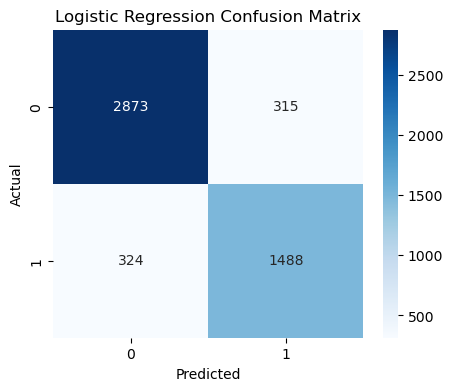

In [80]:
# Initialize the model
lr = LogisticRegression(random_state=42)

# Train the model
lr.fit(X_train_scaled, y_train)

# Make predictions
lr_pred = lr.predict(X_test_scaled)

# Predict probabilities
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

# Calculate evaluation metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

# Print metrics
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')

plt.show()

### Support Vector Machine (SVM)

Train and evaluate the Support Vector Machine model.

Accuracy : 0.9822
Precision: 0.9710
Recall   : 0.9801
F1-Score : 0.9756
ROC-AUC  : 0.9985

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3188
           1       0.97      0.98      0.98      1812

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



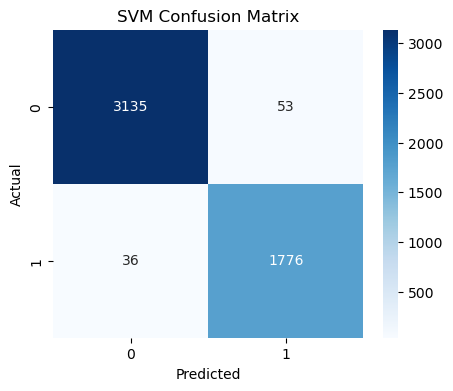

In [81]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:,1]
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)
svm_auc = roc_auc_score(y_test, svm_prob)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")
print(f"ROC-AUC  : {svm_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')

plt.show()

### Gaussian Naive Bayes

Train and evaluate the Gaussian Naive Bayes model.

Accuracy : 0.8614
Precision: 0.7638
Recall   : 0.8940
F1-Score : 0.8238
ROC-AUC  : 0.9260

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.84      0.89      3188
           1       0.76      0.89      0.82      1812

    accuracy                           0.86      5000
   macro avg       0.85      0.87      0.85      5000
weighted avg       0.87      0.86      0.86      5000



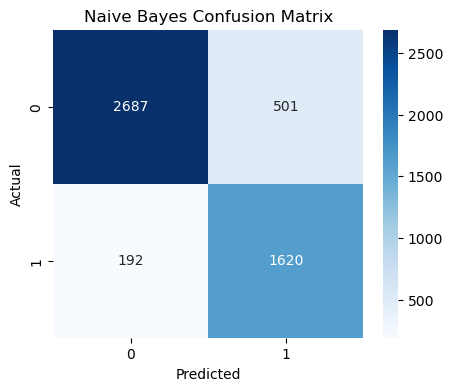

In [82]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)

nb_prob = nb.predict_proba(X_test_scaled)[:,1]

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)
nb_auc = roc_auc_score(y_test, nb_prob)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1-Score : {nb_f1:.4f}")
print(f"ROC-AUC  : {nb_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')

plt.show()

### Decision Tree

Train and evaluate the Decision Tree model.

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3188
           1       1.00      1.00      1.00      1812

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



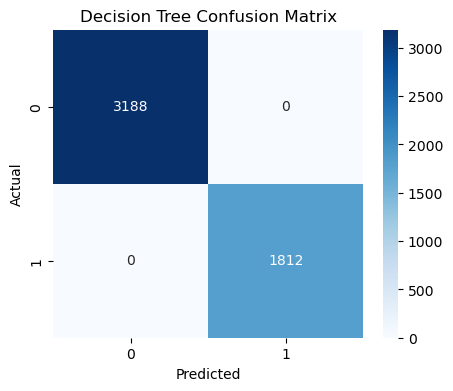

In [83]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:,1]

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')

plt.show()

### Random Forest

Train and evaluate the Random Forest model.

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3188
           1       1.00      1.00      1.00      1812

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



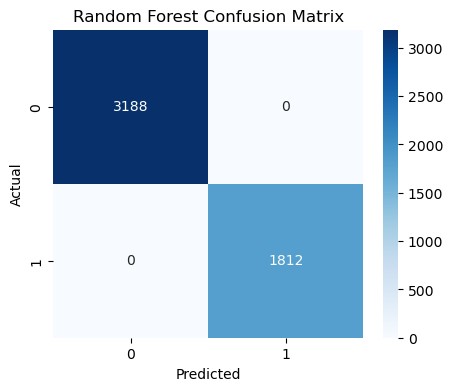

In [89]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = dt.predict(X_test)

rf_prob = dt.predict_proba(X_test)[:,1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

### XGBoost

Train and evaluate the XGBoost model.

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3188
           1       1.00      1.00      1.00      1812

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



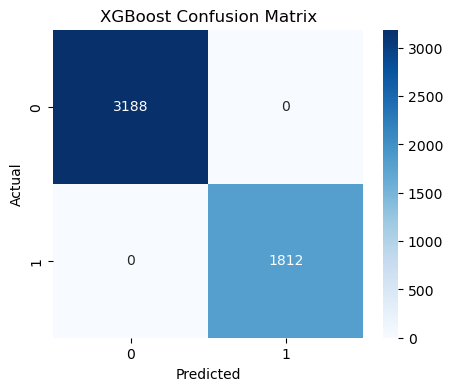

In [88]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

xgb_pred = dt.predict(X_test)

xgb_prob = dt.predict_proba(X_test)[:,1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')

plt.show()

### AdaBoost Model
Train and evaluate the AdaBoost Model

Evaluation Metrics:
------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
ROC-AUC   : 1.0000

Classification Report:
------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3188
           1       1.00      1.00      1.00      1812

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



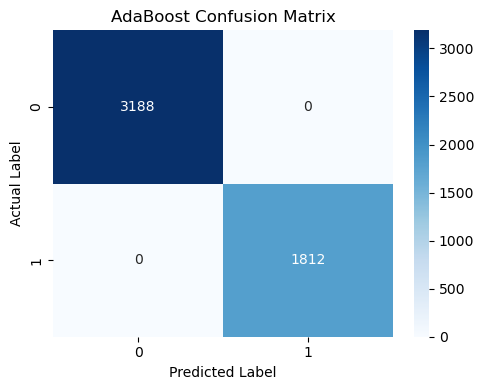

In [91]:
# Initialize the AdaBoost model
ab = AdaBoostClassifier(random_state=42)

# Train the model
ab.fit(X_train, y_train)

# Make predictions on the test set
ab_pred = ab.predict(X_test)

# Predict probabilities for ROC-AUC calculation
ab_prob = ab.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
ab_accuracy = accuracy_score(y_test, ab_pred)
ab_precision = precision_score(y_test, ab_pred)
ab_recall = recall_score(y_test, ab_pred)
ab_f1 = f1_score(y_test, ab_pred)
ab_auc = roc_auc_score(y_test, ab_prob)

# Print evaluation metrics
print("Evaluation Metrics:")
print("-" * 30)
print(f"Accuracy  : {ab_accuracy:.4f}")
print(f"Precision : {ab_precision:.4f}")
print(f"Recall    : {ab_recall:.4f}")
print(f"F1-Score  : {ab_f1:.4f}")
print(f"ROC-AUC   : {ab_auc:.4f}")

# Display classification report
print("\nClassification Report:")
print("-" * 30)
print(classification_report(y_test, ab_pred))

# Compute confusion matrix
cm = confusion_matrix(y_test, ab_pred)

# Visualize confusion matrix
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('AdaBoost Confusion Matrix')

plt.tight_layout()

plt.show()

# Compare Model Performance

Creating a dataframe containing the performance metrics of all models.

In [92]:
results_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'SVM',
        'Naive Bayes',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'XGBoost'
    ],

    'Accuracy': [lr_accuracy, svm_accuracy, nb_accuracy, dt_accuracy, rf_accuracy, ab_accuracy, xgb_accuracy],

    'Precision': [lr_precision, svm_precision, nb_precision, dt_precision, rf_precision, ab_precision, xgb_precision],

    'Recall': [lr_recall, svm_recall, nb_recall, dt_recall, rf_recall, ab_recall, xgb_recall],

    'F1-Score': [lr_f1, svm_f1, nb_f1, dt_f1, rf_f1, ab_f1, xgb_f1],

    'ROC-AUC': [lr_auc, svm_auc, nb_auc, dt_auc, rf_auc, ab_auc, xgb_auc]
})
 
results_df.sort_values(by='F1-Score', ascending=False, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Decision Tree,1.0000,1.000000,1.000000,1.000000,1.000000
4,Random Forest,1.0000,1.000000,1.000000,1.000000,1.000000
5,AdaBoost,1.0000,1.000000,1.000000,1.000000,1.000000
6,XGBoost,1.0000,1.000000,1.000000,1.000000,1.000000
1,SVM,0.9822,0.971022,0.980132,0.975556,0.998472
2,Naive Bayes,0.8614,0.763791,0.894040,0.823799,0.926040
0,Logistic Regression,0.8722,0.825291,0.821192,0.823237,0.936217


Model Comparison

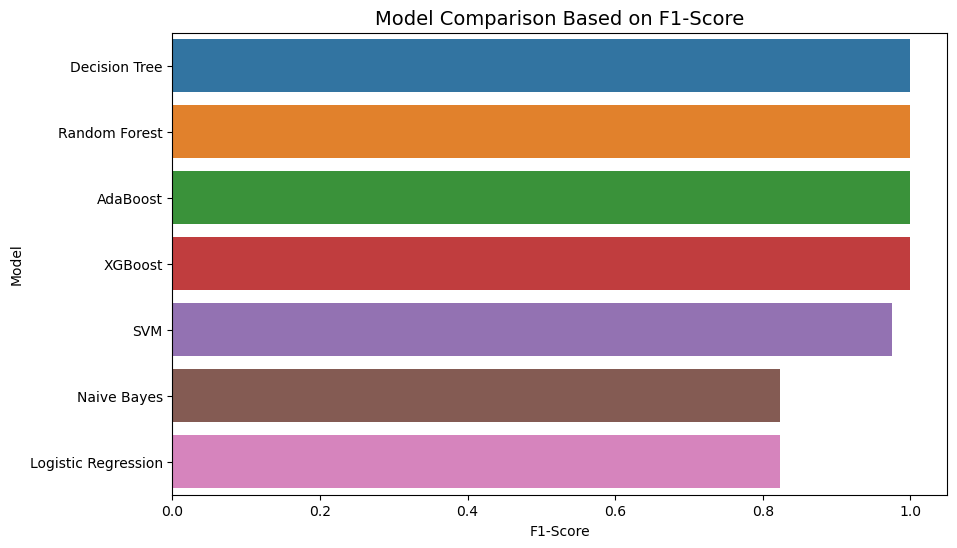

In [93]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='F1-Score',
    y='Model'
)

plt.title(
    'Model Comparison Based on F1-Score',
    fontsize=14
)

plt.xlabel('F1-Score')
plt.ylabel('Model')

plt.show()

Examining which features contributed more to the training

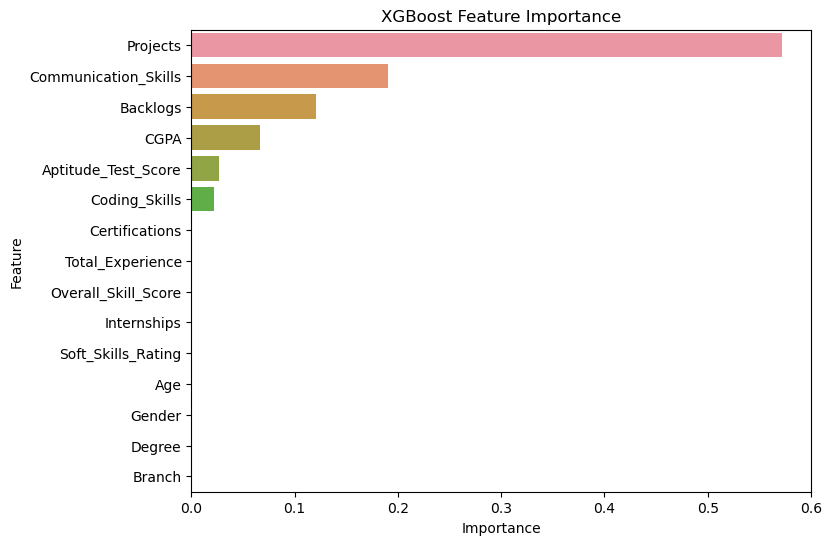

In [95]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('XGBoost Feature Importance')

plt.show()

In [96]:
pd.crosstab(
    train_df['Projects'],
    train_df['Placement_Status'],
    normalize='index'
)

Placement_Status,0,1
Projects,,
1,1.000000,0.000000
2,1.000000,0.000000
3,0.924746,0.075254
4,0.494153,0.505847
5,0.329625,0.670375
6,0.246216,0.753784


### Insight

Feature importance analysis revealed that the number of projects completed was the most influential feature, followed by communication skills and backlog count.

Further investigation showed a strong relationship between the number of projects and placement status. Students with one or two projects were never placed, while the probability of placement increased significantly as the number of projects increased.

Because this synthetic dataset contains strong deterministic relationships, tree-based models such as Decision Tree, Random Forest, AdaBoost, and XGBoost were able to learn these patterns almost perfectly. As a result, these models achieved perfect classification performance on the test set.

This behavior indicates that the dataset is highly separable and easier to classify than real-world placement datasets, where the relationships between features and placement outcomes are usually more complex and less deterministic.